# CIFAR10 with CNNs
Simple starter notebook to benchmark your own CNN with PyTorch on the CIFAR-10 dataset.

OBS.:

- The main code is basically done, so focus on training the models and searching for the best hyperparameters and architectures.
- You are not required to use this exact code or even the PyTorch library.
- It is recommended to use execution environments with GPU access (such as Google Colab), since larger models will take more time to train.
- Remember to document the history of your experiments and which results motivated the changes in subsequent experiments.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 15.0 MB/s eta 0:00:00


In [ ]:
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from tqdm import tqdm

import optuna
from sklearn.model_selection import KFold, train_test_split
from torch.utils.data import DataLoader, Subset

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo em uso: {device}")

Dispositivo em uso: cuda


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # EfficientNet precisa disso
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)


100%|██████████| 170M/170M [00:03<00:00, 42.6MB/s]


In [ ]:
subset_size = 10000 # subconjunto pra ir mais rápido

train_indices = list(range(len(train_dataset)))
train_labels = [train_dataset[i][1] for i in train_indices]

search_indices, _ = train_test_split(
    train_indices,
    train_size=subset_size,
    stratify=train_labels, # garante a mesma quantidade por classe
    random_state=42
)

search_dataset = Subset(train_dataset, search_indices) # só no optuna

print(f"Subconjunto de busca criado com {len(search_dataset)} imagens.")
print(f"Representa {len(search_dataset)//10} imagens por classe.")

Subconjunto de busca criado com 10000 imagens.
Representa 1000 imagens por classe.


In [ ]:
def final_evaluation_cnn(best_model, test_loader):
    best_model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device) # Usa o dispositivo dinâmico
            outputs = best_model(images)
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.numpy())

    print("\nRelatório de Classificação Final:")
    print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
    plt.ylabel('Real')
    plt.xlabel('Previsto')
    plt.title('Matriz de Confusão - CNN')
    plt.show()

In [ ]:
import torchvision.models as models

class CNN(nn.Module):
    def __init__(self, dropout_rate):
        super(CNN, self).__init__()

        # Modelo pré-treinado
        self.model = models.efficientnet_b0(pretrained=True)

        # Congela camadas iniciais (transfer learning)
        for param in self.model.features.parameters():
            param.requires_grad = False

        # Substitui a camada final
        in_features = self.model.classifier[1].in_features

        self.model.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, 10)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
def objective_cnn(trial):
    conv_arch_dict = {
        "Pequena": (32, 64, 128),
        "Media": (64, 128, 256),
        "Crescente": (32, 128, 512),
        "Grande": (64, 256, 512)

    }

    arch_name = trial.suggest_categorical("conv_arch", list(conv_arch_dict.keys()))
    conv_filters = conv_arch_dict[arch_name]

    kernel_size = trial.suggest_categorical("kernel_size", [3, 5])
    fc_size = trial.suggest_categorical("fc_size", [128, 256, 512])

    dropout_rate = trial.suggest_float("dropout", 0.2, 0.5)
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-4, log=True)

    # Removida a linha duplicada de batch_size
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD"])
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128]) # Mantendo esta linha

    activations = {
        "ReLU": nn.ReLU(),
        "Tanh": nn.Tanh(),
        "LeakyReLU": nn.LeakyReLU()
    }
    activation_name = trial.suggest_categorical("activation", list(activations.keys())) # Adicionada a sugestão para activation_name

    print(f"\nIniciando Trial CNN #{trial.number}")
    print(f"Arquitetura: {arch_name} Filtros: {conv_filters} | Kernel: {kernel_size}")
    print(f"Otimizador: {optimizer_name} | Ativação: {activation_name} | LR: {lr:.5f}")

    k_folds = 3
    kfold = KFold(n_splits=k_folds, shuffle=True)
    fold_accuracies = []

    for fold, (train_ids, val_ids) in enumerate(kfold.split(search_dataset)):
        train_sub = Subset(search_dataset, train_ids)
        val_sub = Subset(search_dataset, val_ids)
        t_loader = DataLoader(train_sub, batch_size=batch_size, shuffle=True)
        v_loader = DataLoader(val_sub, batch_size=batch_size, shuffle=False)

        # Usando .to(device) em vez de .cuda()
        model = CNN(dropout_rate).to(device)
        if optimizer_name == "Adam":
            optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        else:
            optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)

        for epoch in range(5):
            model.train()
            for images, labels in t_loader:
                # Usando .to(device)
                images = images.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()
                outputs = model(images)
                loss = nn.CrossEntropyLoss()(outputs, labels)
                loss.backward()
                optimizer.step()

            scheduler.step(loss)
            if epoch == 3:
              for param in model.model.features.parameters():
                  param.requires_grad = True

        model.eval()
        correct = 0
        with torch.no_grad():
            for images, labels in v_loader:
                # Usando .to(device)
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                pred = outputs.argmax(dim=1)
                correct += pred.eq(labels).sum().item()

        acc = correct / len(val_ids)
        fold_accuracies.append(acc)

    mean_accuracy = np.mean(fold_accuracies)
    print(f"RESULTADO TRIAL CNN #{trial.number}: Acurácia Média (CV) = {mean_accuracy:.4f}")

    return mean_accuracy

In [ ]:
study_cnn = optuna.create_study(direction="maximize")
study_cnn.optimize(objective_cnn, n_trials=50)

print(f"\nMelhor Acurácia de Validação CNN: {study_cnn.best_value:.4f}")
print(f"Melhores Parâmetros CNN: {study_cnn.best_params}")

[I 2026-04-02 13:45:10,719] A new study created in memory with name: no-name-ffb6eaf7-025d-4d88-a596-3ad6bad677bb
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Iniciando Trial CNN #0
Arquitetura: Pequena Filtros: (32, 64, 128) | Kernel: 3
Otimizador: Adam | Ativação: LeakyReLU | LR: 0.00021
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 158MB/s]
/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1694: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  current = float(metrics)
[I 2026-04-02 13:50:36,019] Trial 0 finished with value: 0.890799187897194 and parameters: {'conv_arch': 'Pequena', 'kernel_size': 3, 'fc_size': 128, 'dropout': 0.3250471993278319, 'lr': 0.00021499547472990344, 'weight_decay': 3.1224765320045754e-06, 'optimizer': 'Adam', 'batch_size': 128, 'activation': 'LeakyReLU'}. Best is trial 0 with value: 0.890799187897194.


RESULTADO TRIAL CNN #0: Acurácia Média (CV) = 0.8908

Iniciando Trial CNN #1
Arquitetura: Pequena Filtros: (32, 64, 128) | Kernel: 3
Otimizador: Adam | Ativação: LeakyReLU | LR: 0.00009


[I 2026-04-02 13:56:27,566] Trial 1 finished with value: 0.8931999078732109 and parameters: {'conv_arch': 'Pequena', 'kernel_size': 3, 'fc_size': 128, 'dropout': 0.44530393518311107, 'lr': 9.364822714335608e-05, 'weight_decay': 1.741376453185473e-06, 'optimizer': 'Adam', 'batch_size': 16, 'activation': 'LeakyReLU'}. Best is trial 1 with value: 0.8931999078732109.


...

RESULTADO TRIAL CNN #47: Acurácia Média (CV) = 0.8828

Iniciando Trial CNN #48
Arquitetura: Grande Filtros: (64, 256, 512) | Kernel: 3
Otimizador: Adam | Ativação: ReLU | LR: 0.00047


[I 2026-04-02 18:08:25,163] Trial 48 finished with value: 0.9010008079392223 and parameters: {'conv_arch': 'Grande', 'kernel_size': 3, 'fc_size': 512, 'dropout': 0.23148635796406664, 'lr': 0.0004726799297913162, 'weight_decay': 3.168372242873829e-05, 'optimizer': 'Adam', 'batch_size': 64, 'activation': 'ReLU'}. Best is trial 29 with value: 0.9073004481011989.


RESULTADO TRIAL CNN #48: Acurácia Média (CV) = 0.9010

Iniciando Trial CNN #49
Arquitetura: Pequena Filtros: (32, 64, 128) | Kernel: 5
Otimizador: SGD | Ativação: ReLU | LR: 0.00075


[I 2026-04-02 18:13:34,723] Trial 49 finished with value: 0.8072991162343589 and parameters: {'conv_arch': 'Pequena', 'kernel_size': 5, 'fc_size': 512, 'dropout': 0.4344623044123813, 'lr': 0.0007530945282921442, 'weight_decay': 8.182911462330951e-06, 'optimizer': 'SGD', 'batch_size': 32, 'activation': 'ReLU'}. Best is trial 29 with value: 0.9073004481011989.


RESULTADO TRIAL CNN #49: Acurácia Média (CV) = 0.8073

Melhor Acurácia de Validação CNN: 0.9073
Melhores Parâmetros CNN: {'conv_arch': 'Grande', 'kernel_size': 5, 'fc_size': 256, 'dropout': 0.3287909510004368, 'lr': 0.0005522297927240294, 'weight_decay': 4.241299226455235e-06, 'optimizer': 'Adam', 'batch_size': 128, 'activation': 'ReLU'}


In [ ]:
# Parâmetros encontrados
best_params = {
    'dropout': 0.3287909510004368,
    'lr': 0.0005522297927240294,
    'weight_decay': 4.241299226455235e-06,
    'optimizer': 'Adam',
    'batch_size': 128
}

print(f"\nTreinando o modelo final com EfficientNet...")

# Modelo (nova versão)
best_cnn_model = CNN(
    dropout_rate=best_params["dropout"]
).to(device)

# Otimizador corrigido
if best_params["optimizer"] == "Adam":
    optimizer = torch.optim.Adam(
        best_cnn_model.parameters(),
        lr=best_params["lr"],
        weight_decay=best_params["weight_decay"]
    )
else:
    optimizer = torch.optim.SGD(
        best_cnn_model.parameters(),
        lr=best_params["lr"],
        momentum=0.9,
        weight_decay=best_params["weight_decay"]
    )

# Scheduler (melhoria importante)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)

full_train_loader = DataLoader(
    train_dataset,
    batch_size=best_params["batch_size"],
    shuffle=True
)

best_loss = float('inf')
patience = 5
patience_counter = 0
max_epochs = 50
best_model_path = '/content/drive/MyDrive/melhor_modelo_cnn_final.pth'

for epoch in range(max_epochs):
    best_cnn_model.train()
    epoch_loss = 0.0

    # 🔥 Fine-tuning (descongela depois de 3 épocas)
    if epoch == 3:
        for param in best_cnn_model.model.features.parameters():
            param.requires_grad = True

    for images, labels in tqdm(full_train_loader, desc=f"Epoch {epoch+1}/{max_epochs}", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = best_cnn_model(images)
        loss = nn.CrossEntropyLoss()(outputs, labels)

        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(full_train_loader)
    print(f"Época {epoch+1} finalizada. Loss Média: {avg_epoch_loss:.4f}")

    scheduler.step(avg_epoch_loss)

    if avg_epoch_loss < best_loss:
        best_loss = avg_epoch_loss
        patience_counter = 0
        torch.save(best_cnn_model.state_dict(), best_model_path)
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly Stopping ativado na época {epoch+1}.")
            break

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Treinando o modelo final com EfficientNet...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 150MB/s]


Época 1 finalizada. Loss Média: 1.3121


Época 2 finalizada. Loss Média: 0.9481


...

Época 46 finalizada. Loss Média: 0.0018


Época 47 finalizada. Loss Média: 0.0023


Época 48 finalizada. Loss Média: 0.0012


Época 49 finalizada. Loss Média: 0.0013


Época 50 finalizada. Loss Média: 0.0009



Avaliação no conjunto de testes:

Relatório de Classificação Final:
              precision    recall  f1-score   support

    airplane       0.97      0.98      0.98      1000
  automobile       0.97      0.98      0.98      1000
        bird       0.96      0.96      0.96      1000
         cat       0.95      0.92      0.94      1000
        deer       0.98      0.97      0.97      1000
         dog       0.94      0.95      0.95      1000
        frog       0.97      0.98      0.98      1000
       horse       0.99      0.98      0.98      1000
        ship       0.98      0.99      0.98      1000
       truck       0.98      0.97      0.98      1000

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



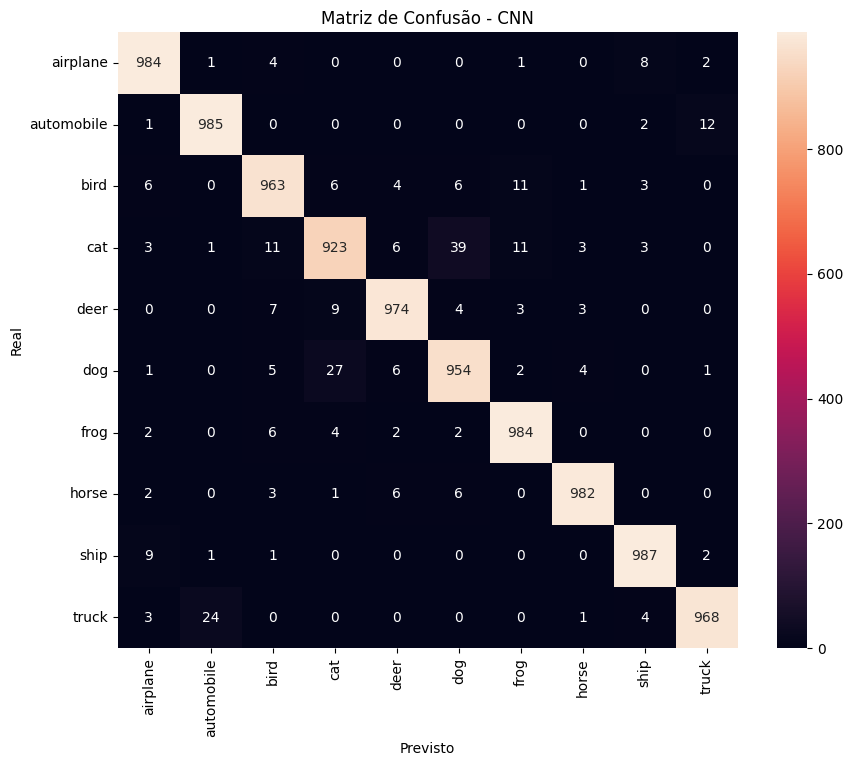

In [ ]:

print("\nAvaliação no conjunto de testes:")

best_cnn_model.load_state_dict(torch.load(best_model_path, map_location=device))

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

final_evaluation_cnn(best_cnn_model, test_loader)